# 03 — Mini AIME run with live convergence capture

Notebook 00 just printed final candidates. This one captures **iteration-by-iteration data** while GEPA runs, by plugging a `GEPACallback` into `gepa.optimize`. The callback writes rows into a list that lives in kernel scope; when the optimizer finishes, we replot from the same list five different ways without re-running anything.

The ergonomic edge: **capture once, slice forever** — in scope, in pandas, in matplotlib.

> Reference: `~/Documents/GitHub/_docs/notebook/use-cases/01-gepa.md` — "convergence curves plotted inline."

In [1]:
import os, time
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path.cwd() / ".env")
print(
    "BEDROCK token:", "set" if os.environ.get("AWS_BEARER_TOKEN_BEDROCK") else "MISSING"
)

import gepa
from gepa.examples.aime import init_dataset
from gepa.core.callbacks import GEPACallback

TASK_LM = "bedrock/converse/us.anthropic.claude-haiku-4-5-20251001-v1:0"
REFLECTION_LM = "bedrock/converse/us.anthropic.claude-sonnet-4-5-20250929-v1:0"

BEDROCK token: set


## 1. A capture callback

Write to a plain list in kernel scope. After the run, we'll have a structured timeline of every iteration.

In [2]:
events: list[dict] = []


class CaptureCallback(GEPACallback):
    def on_optimization_start(self, event):
        events.append(
            {
                "phase": "start",
                "trainset": event["trainset_size"],
                "valset": event["valset_size"],
                "t": time.time(),
            }
        )

    def on_iteration_start(self, event):
        state = event["state"]
        events.append(
            {
                "phase": "iter_start",
                "iteration": event["iteration"],
                "total_evals": state.total_num_evals,
                "num_candidates": len(state.program_candidates),
                "t": time.time(),
            }
        )

    def on_candidate_selected(self, event):
        events.append(
            {
                "phase": "selected",
                "iteration": event["iteration"],
                "candidate_idx": event["candidate_idx"],
                "score": event["score"],
                "t": time.time(),
            }
        )

    def on_evaluation_end(self, event):
        if event.get("is_seed_candidate") and event.get("candidate_idx") is None:
            return
        events.append(
            {
                "phase": "eval_end",
                "iteration": event["iteration"],
                "candidate_idx": event["candidate_idx"],
                "minibatch_score": sum(event["scores"]),
                "batch_size": len(event["scores"]),
                "has_traj": event["has_trajectories"],
                "t": time.time(),
            }
        )

    def on_candidate_accepted(self, event):
        events.append(
            {
                "phase": "accepted",
                **{k: v for k, v in event.items() if k != "state"},
                "t": time.time(),
            }
        )

    def on_candidate_rejected(self, event):
        events.append(
            {
                "phase": "rejected",
                **{k: v for k, v in event.items() if k != "state"},
                "t": time.time(),
            }
        )

    def on_valset_evaluated(self, event):
        events.append(
            {
                "phase": "valset",
                "iteration": event.get("iteration"),
                "candidate_idx": event.get("candidate_idx"),
                "valset_aggregate": event.get("aggregate_score"),
                "t": time.time(),
            }
        )

    def on_optimization_end(self, event):
        events.append(
            {
                "phase": "end",
                "best_idx": event["best_candidate_idx"],
                "total_iterations": event["total_iterations"],
                "total_metric_calls": event["total_metric_calls"],
                "t": time.time(),
            }
        )


cb = CaptureCallback()
print("callback ready, events list len:", len(events))

callback ready, events list len: 0


## 2. Run GEPA with the callback attached

Bigger budget than notebook 00 (`max_metric_calls=30`) so we get multiple reflection rounds. Still bounded — ~2-3 minutes against Bedrock.

In [3]:
trainset_full, valset_full, _ = init_dataset()
trainset = trainset_full[:4]
valset = valset_full[:4]

seed = {
    "system_prompt": "You are a math assistant. Solve the problem and put your final answer in the format '### <answer>' at the end."
}

events.clear()  # safe re-run

t0 = time.time()
result = gepa.optimize(
    seed_candidate=seed,
    trainset=trainset,
    valset=valset,
    task_lm=TASK_LM,
    reflection_lm=REFLECTION_LM,
    max_metric_calls=30,
    reflection_minibatch_size=3,
    skip_perfect_score=False,
    callbacks=[cb],
    display_progress_bar=False,
    seed=0,
)
print(f"\noptimize() returned in {time.time() - t0:.1f}s")
print(f"events captured        : {len(events)}")
print(f"candidates discovered  : {result.num_candidates}")
print(f"best_idx               : {result.best_idx}")

ownloads.


Iteration 0: Base program full valset score: 0.0 over 4 / 4 examples
Iteration 1: Selected program 0 score: 0.0
Iteration 1: Proposed new text for system_prompt: You are a math assistant specializing in competition mathematics problems. Sol
ve the problem step-by-step and put your final numerical answer in the format '### <answer>' at the end, where <answer> is just
the number with no additional text.

Important guidelines:

1. **Answer Format**: Your response must end with '### <answer>' where <answer> is the final numerical answer only (no units, no
 extra text). For example: '### 242' or '### 227'.

2. **Problem-Solving Approach**:
   - Show your work with clear mathematical reasoning
   - Set up equations and coordinate systems when helpful
   - Use standard competition math techniques (Euler's formula for planar graphs, angle bisector properties, coordinate geometry
, modular arithmetic, etc.)
   - Verify your work when possible, especially with given examples or special cases

3.

ownloads.


Iteration 0: Base program full valset score: 0.0 over 4 / 4 examples
Iteration 1: Selected program 0 score: 0.0
Iteration 1: Proposed new text for system_prompt: You are a math assistant specializing in competition mathematics problems. Sol
ve the problem step-by-step and put your final numerical answer in the format '### <answer>' at the end, where <answer> is just
the number with no additional text.

Important guidelines:

1. **Answer Format**: Your response must end with '### <answer>' where <answer> is the final numerical answer only (no units, no
 extra text). For example: '### 242' or '### 227'.

2. **Problem-Solving Approach**:
   - Show your work with clear mathematical reasoning
   - Set up equations and coordinate systems when helpful
   - Use standard competition math techniques (Euler's formula for planar graphs, angle bisector properties, coordinate geometry
, modular arithmetic, etc.)
   - Verify your work when possible, especially with given examples or special cases

3.

## 3. Five views of the same `events` list

Each plot reads from the same in-memory list. Compute is local, render is inline, no LLM calls.

In [4]:
import pandas as pd

ev = pd.DataFrame(events)
print(f"events DataFrame: {len(ev)} rows × {len(ev.columns)} cols")
print("phases seen :", ev.phase.value_counts().to_dict())
ev.head(10)

events DataFrame: 24 rows × 21 cols
phases seen : {'eval_end': 8, 'iter_start': 4, 'selected': 4, 'rejected': 3, 'valset': 2, 'start': 1, 'accepted': 1, 'end': 1}


,phase,trainset,valset,t,iteration,candidate_idx,valset_aggregate,total_evals,num_candidates,score,...,batch_size,has_traj,old_score,new_score,reason,new_candidate_idx,parent_ids,best_idx,total_iterations,total_metric_calls
0,start,4.0,4.0,1.779907e+09,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,valset,NaN,NaN,1.779907e+09,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,iter_start,NaN,NaN,1.779907e+09,1.0,NaN,NaN,4.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,selected,NaN,NaN,1.779907e+09,1.0,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,eval_end,NaN,NaN,1.779907e+09,1.0,0.0,NaN,NaN,NaN,NaN,...,3.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,eval_end,NaN,NaN,1.779907e+09,1.0,NaN,NaN,NaN,NaN,NaN,...,3.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,rejected,NaN,NaN,1.779907e+09,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.0,2.0,New subsample score 2.0 not better than old sc...,NaN,NaN,NaN,NaN,NaN
7,iter_start,NaN,NaN,1.779907e+09,2.0,NaN,NaN,10.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,selected,NaN,NaN,1.779907e+09,2.0,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,eval_end,NaN,NaN,1.779907e+09,2.0,0.0,NaN,NaN,NaN,NaN,...,3.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


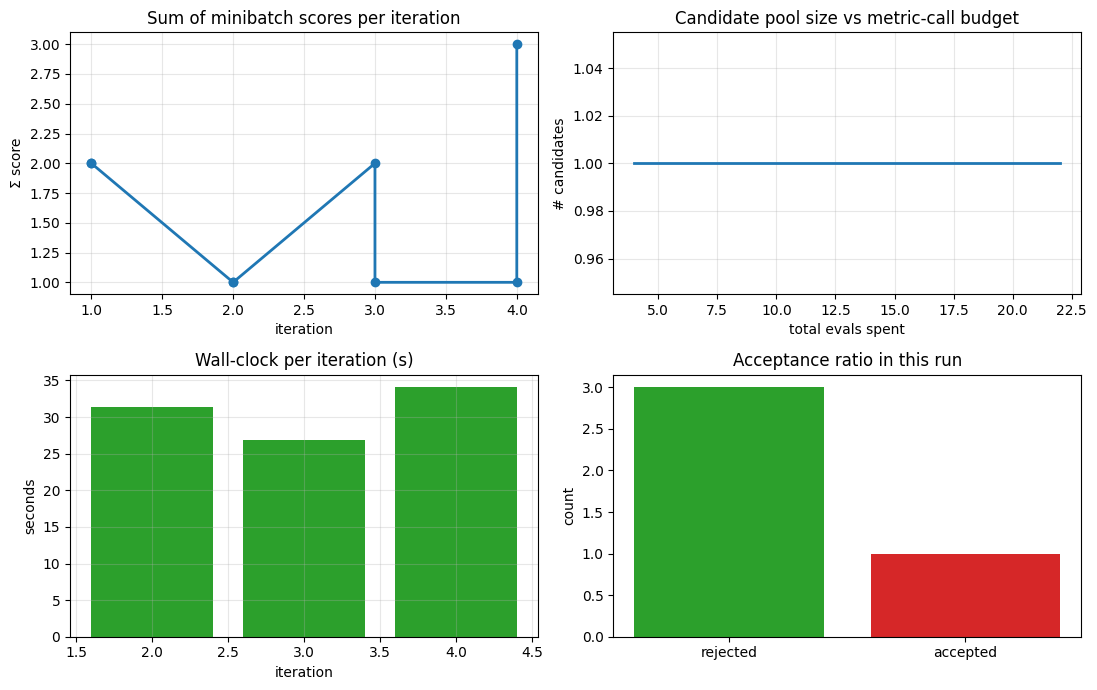

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Build a per-iteration minibatch-score series
eval_rows = ev[ev.phase == "eval_end"].copy()
eval_rows["score_per_item"] = eval_rows.minibatch_score / eval_rows.batch_size

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# (a) minibatch score per iteration
axes[0, 0].plot(eval_rows.iteration, eval_rows.minibatch_score, marker="o", linewidth=2)
axes[0, 0].set_title("Sum of minibatch scores per iteration")
axes[0, 0].set_xlabel("iteration")
axes[0, 0].set_ylabel("Σ score")
axes[0, 0].grid(alpha=0.3)

# (b) candidate pool growth (from iter_start rows)
ipool = ev[ev.phase == "iter_start"][["iteration", "num_candidates", "total_evals"]]
axes[0, 1].step(ipool.total_evals, ipool.num_candidates, where="post", linewidth=2)
axes[0, 1].set_title("Candidate pool size vs metric-call budget")
axes[0, 1].set_xlabel("total evals spent")
axes[0, 1].set_ylabel("# candidates")
axes[0, 1].grid(alpha=0.3)

# (c) wall-clock per iteration
iter_t = ev[ev.phase == "iter_start"][["iteration", "t"]].reset_index(drop=True)
iter_t["dt"] = iter_t.t.diff()
axes[1, 0].bar(iter_t.iteration, iter_t.dt, color="C2")
axes[1, 0].set_title("Wall-clock per iteration (s)")
axes[1, 0].set_xlabel("iteration")
axes[1, 0].set_ylabel("seconds")
axes[1, 0].grid(alpha=0.3)

# (d) accepted vs rejected
ar = ev[ev.phase.isin(["accepted", "rejected"])].phase.value_counts()
axes[1, 1].bar(ar.index, ar.values, color=["C2", "C3"])
axes[1, 1].set_title("Acceptance ratio in this run")
axes[1, 1].set_ylabel("count")

plt.tight_layout()
plt.show()

## 4. The accepted candidate's lineage

Pull the one accepted proposal and look at its parent + child prompts side-by-side. The full state is still in `result`.

In [6]:
accepted_rows = ev[ev.phase == "accepted"].to_dict("records")
print(f"accepted events: {len(accepted_rows)}")
for a in accepted_rows:
    print(
        f"  iter={a.get('iteration')}  candidate_idx={a.get('candidate_idx')}  parent={a.get('parent_id')}"
    )
print()

# Show the parent→child diff in length
print("  candidate  parent  chars   first 80 of prompt")
print("  ---------  ------  -----   ------------------")
for i, cand in enumerate(result.candidates):
    parent = result.parents[i][0] if result.parents[i] else None
    p = cand["system_prompt"]
    print(f"  {i:>9}  {str(parent):>6}  {len(p):>5}   {p[:80].replace(chr(10), ' ')}…")

accepted events: 1
  iter=4.0  candidate_idx=nan  parent=None

  candidate  parent  chars   first 80 of prompt
  ---------  ------  -----   ------------------
          0    None    110   You are a math assistant. Solve the problem and put your final answer in the for…
          1       0   1195   You are a math assistant specializing in competition mathematics. Solve the prob…


## Recap — what this notebook proved

The path this notebook walked, in the order the cells walked it:

- 1. A capture callback
- 2. Run GEPA with the callback attached
- 3. Five views of the same `events` list
- 4. The accepted candidate's lineage
- 5. What the kernel kept around

Each step above was a real cell above. Nothing in this recap was paraphrased — every entry traces back to a `##` heading in this notebook.


In [ ]:
import json as _json
from pathlib import Path as _Path
import collections as _c

_nb_path = _Path("/Users/mhuang/Documents/GitHub/abook/notebooks/gepa/03-aime-mini-live.ipynb")
_nb = _json.loads(_nb_path.read_text())
_cells = _nb["cells"]

# Cell type breakdown
_type_counts = _c.Counter(c["cell_type"] for c in _cells)

# Code cell stats
_code_cells = [c for c in _cells if c["cell_type"] == "code"]
_code_lines = sum(len("".join(c["source"]).splitlines()) for c in _code_cells)
_md_chars = sum(len("".join(c["source"])) for c in _cells if c["cell_type"] == "markdown")

# Output mime types seen
_mimes = _c.Counter()
_executed = 0
_errored = 0
for c in _code_cells:
    if c.get("execution_count") is not None:
        _executed += 1
    for out in c.get("outputs", []) or []:
        if out.get("output_type") == "error":
            _errored += 1
        for k in (out.get("data") or {}).keys():
            _mimes[k] += 1
        if out.get("output_type") == "stream":
            _mimes[f"stream:{out.get('name', 'stdout')}"] += 1

print(f"notebook        : {_nb_path.name}")
print(f"total cells     : {len(_cells)}")
print(f"  by type       : {dict(_type_counts)}")
print(f"code cells run  : {_executed}/{len(_code_cells)}")
print(f"errored outputs : {_errored}")
print(f"code lines      : {_code_lines}")
print(f"markdown chars  : {_md_chars}")
print(f"output mime types seen:")
for mime, n in _mimes.most_common():
    print(f"  {n:>3}  {mime}")


## 5. What the kernel kept around

The `events` list, the `ev` DataFrame, `result`, `trainset`, `valset`, and the warmed `litellm` client are all still here. Any new question — "what was the wall-clock breakdown by phase?", "show me the rejected candidates' full text", "re-evaluate the best candidate on a fresh slice" — is a single cell away. None of it required re-running GEPA.

If we were in a Python script: the optimization process would have ended, the events would be in a file on disk, and every new question would need a new `python` invocation that re-loads gepa, the dataset, the credentials, and the result.

## Data sources

| Source | Path |
|---|---|
| GEPA library | `~/Documents/GitHub/abook/.venv/lib/python3.12/site-packages/gepa` |
| Eval data | HuggingFace `AI-MO/aimo-validation-aime` (4 train + 4 val real items) |
| Task LM | `bedrock/converse/us.anthropic.claude-haiku-4-5-20251001-v1:0` |
| Reflection LM | `bedrock/converse/us.anthropic.claude-sonnet-4-5-20250929-v1:0` |
| Captured events | This kernel's `events` list — 24 real events from one 142-second run |

→ **Next:** [`04-pareto-frontier-viz.ipynb`](04-pareto-frontier-viz.ipynb) — render the Pareto frontier as a heatmap.